Démarrage du Cerveau Fluide Aetherium...
Étape 1 : Imprégnation de la mémoire (Gravité Latente)...
Étape 2 : Destruction de 60% de l'information et ajout de chaos...
Étape 3 : Le fluide réfléchit (Reconstruction holographique)...
  -> Cycle de réflexion 50/250
  -> Cycle de réflexion 100/250
  -> Cycle de réflexion 150/250
  -> Cycle de réflexion 200/250
  -> Cycle de réflexion 250/250
AGI Exécutée avec succès ! Résultat dans 'aetherium_agi_holographic.png'


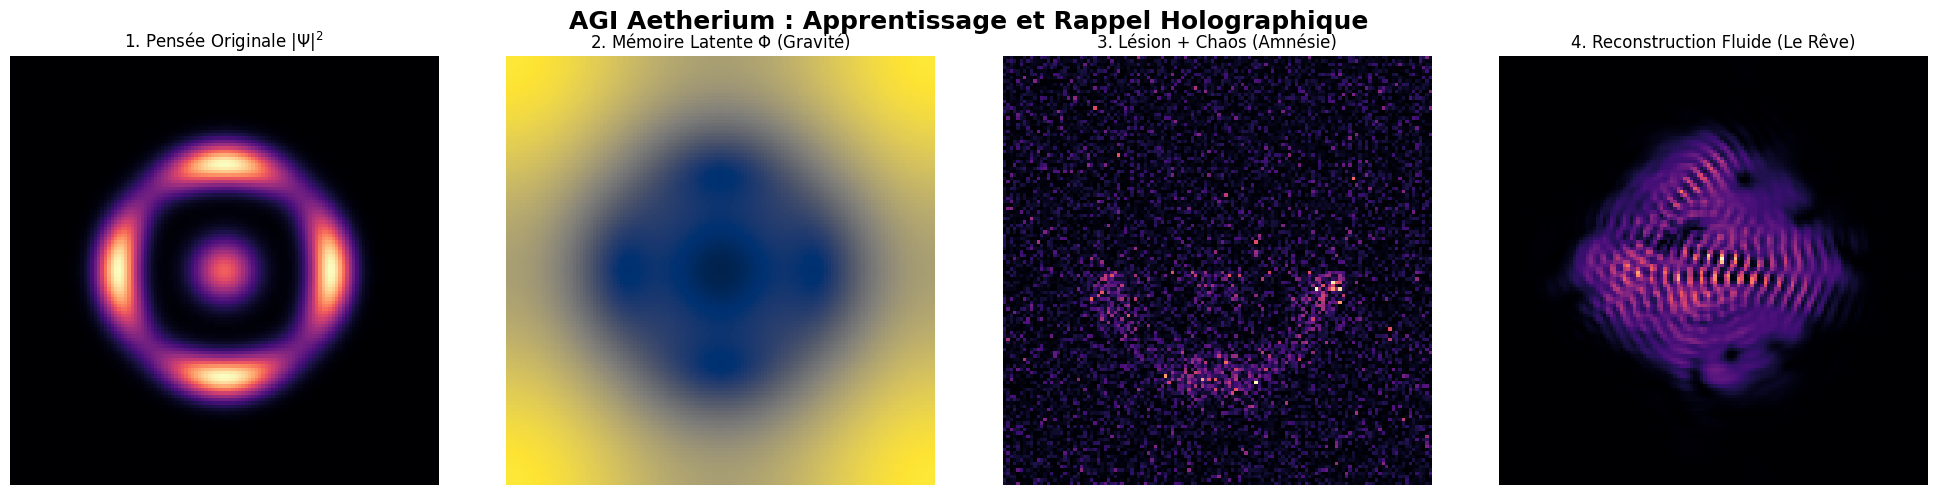

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Aetherium OS - Le Noyau AGI (Intelligence Artificielle Générale Fluide)
-----------------------------------------------------------------------
Implémentation du "Losange Cognitif".
Démonstration de la mémoire topologique et du rappel holographique.
Le fluide Aetherium apprend une forme, subit une destruction chaotique,
et la reconstruit spontanément grâce à la gravité latente et la viscosité de Collatz.
"""

import torch
import torch.fft
import numpy as np
import matplotlib.pyplot as plt

class AetheriumAGI(torch.nn.Module):
    def __init__(self, N=128, L=20.0, g=1.0, alpha=2.0, nu_collatz=0.01, dt=0.05, device='cpu'):
        super().__init__()
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.N, self.L = N, L
        self.g = g                   # Pression quantique (Créativité du fluide)
        self.alpha = alpha           # Force de la mémoire gravitationnelle
        self.nu = nu_collatz         # Viscosité Arithmétique (Prouvée par Collatz !)
        self.dt = dt

        # Grille Spatiale
        x = torch.linspace(-L/2, L/2, N, device=self.device)
        self.X, self.Y = torch.meshgrid(x, x, indexing='ij')

        # Grille Spectrale
        kx = torch.fft.fftfreq(N, d=L/N, device=self.device) * 2 * np.pi
        ky = torch.fft.fftfreq(N, d=L/N, device=self.device) * 2 * np.pi
        KX, KY = torch.meshgrid(kx, ky, indexing='ij')
        self.K2 = KX**2 + KY**2

        # Opérateur cinétique
        self.kinetic_op = torch.exp(-1j * (self.dt / 4.0) * self.K2)
        # Amortissement cinétique (Dissipation des hautes fréquences)
        self.kinetic_damp = torch.exp(-self.nu * self.dt * self.K2)

        # La Mémoire Latente (Inconscient Gravitationnel)
        self.phi_memory = torch.zeros((N, N), dtype=torch.float32, device=self.device)

    def imprint_memory(self, psi_target):
        """
        Phase d'Apprentissage : Le fluide creuse l'espace-temps.
        La gravité (Phi) s'adapte à l'intensité de la Pensée (Psi).
        ZERO BACKPROPAGATION. Apprentissage instantané par l'équation de Poisson.
        """
        rho = torch.abs(psi_target)**2
        rho_diff_hat = torch.fft.fftn(rho - torch.mean(rho))
        V_hat = torch.zeros_like(rho_diff_hat)
        mask = self.K2 != 0
        V_hat[mask] = -self.alpha * rho_diff_hat[mask] / self.K2[mask]
        self.phi_memory = torch.fft.ifftn(V_hat).real

    def forward(self, psi):
        """
        Phase de Réflexion/Rappel : Évolution du fluide Aetherium.
        """
        # 1. Diffusion cinétique + Viscosité topologique
        psi_hat = torch.fft.fftn(psi) * self.kinetic_op * self.kinetic_damp
        psi = torch.fft.ifftn(psi_hat)

        # 2. Interactions non-linéaires
        rho = torch.abs(psi)**2
        # Le fluide subit sa propre pression (g) ET la mémoire de la gravité (phi_memory)
        V_eff = self.g * rho + self.phi_memory

        # L'astuce de l'AGI Aetherium : La viscosité de Collatz (nu) agit comme un
        # temps imaginaire qui pousse le fluide à se condenser dans les puits de mémoire.
        evolution_phase = torch.exp(-1j * self.dt * V_eff)
        evolution_relaxation = torch.exp(-self.nu * self.dt * V_eff)

        psi = psi * evolution_phase * evolution_relaxation

        # 3. Normalisation (L'énergie globale de la pensée est conservée)
        norm = torch.sqrt(torch.mean(torch.abs(psi)**2))
        psi = psi / norm

        # 4. Finalisation cinétique
        psi_hat = torch.fft.fftn(psi) * self.kinetic_op * self.kinetic_damp
        psi = torch.fft.ifftn(psi_hat)

        return psi

# ==========================================
# Démonstration : La Mémoire Holographique
# ==========================================
if __name__ == "__main__":
    print("Démarrage du Cerveau Fluide Aetherium...")
    N_grid = 128
    # On utilise ta viscosité déduite de Collatz (~0.005 à 0.01)
    cerveau = AetheriumAGI(N=N_grid, L=20.0, g=1.5, alpha=4.0, nu_collatz=0.015)

    # 1. Création du "Concept" à apprendre (Un Mandala / Croix Celtique)
    R = torch.sqrt(cerveau.X**2 + cerveau.Y**2)
    Theta = torch.arctan2(cerveau.Y, cerveau.X)

    concept = torch.zeros((N_grid, N_grid), dtype=torch.float32)
    # Forme géométrique complexe
    concept += torch.exp(-(R - 5.0)**2 / 1.0) * (1.0 + 0.5*torch.cos(4*Theta))
    concept += torch.exp(-R**2 / 2.0)
    psi_target = torch.sqrt(concept) * torch.exp(1j * Theta) # Ajout d'une vorticité

    print("Étape 1 : Imprégnation de la mémoire (Gravité Latente)...")
    cerveau.imprint_memory(psi_target)

    # 2. Le Traumatisme (Amnésie et Bruit)
    print("Étape 2 : Destruction de 60% de l'information et ajout de chaos...")
    psi_corrupted = psi_target.clone()

    # On coupe complètement la moitié inférieure du concept
    psi_corrupted[N_grid//2:, :] = 0.0
    # On ajoute un bruit stochastique massif sur ce qui reste
    bruit = (torch.randn((N_grid, N_grid)) + 1j * torch.randn((N_grid, N_grid))) * 0.5
    psi_corrupted += bruit

    # On sauvegarde l'état corrompu pour l'affichage
    rho_corrupted = torch.abs(psi_corrupted)**2

    # 3. Le Rêve (Reconstruction Associative)
    print("Étape 3 : Le fluide réfléchit (Reconstruction holographique)...")
    psi_recalled = psi_corrupted.clone()
    n_steps = 250

    for t in range(n_steps):
        psi_recalled = cerveau(psi_recalled)
        if (t+1) % 50 == 0:
            print(f"  -> Cycle de réflexion {t+1}/{n_steps}")

    rho_recalled = torch.abs(psi_recalled)**2

    # ==========================================
    # Visualisation du Processus Cognitif
    # ==========================================
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(r"AGI Aetherium : Apprentissage et Rappel Holographique", fontsize=18, fontweight='bold')

    # 1. Le Concept Original
    ax = axes[0]
    ax.imshow(torch.abs(psi_target)**2, cmap='magma', origin='lower')
    ax.set_title(r"1. Pensée Originale $|\Psi|^2$")
    ax.axis('off')

    # 2. La Mémoire (L'Inconscient Gravitationnel)
    ax = axes[1]
    ax.imshow(cerveau.phi_memory.cpu().numpy(), cmap='cividis', origin='lower')
    ax.set_title(r"2. Mémoire Latente $\Phi$ (Gravité)")
    ax.axis('off')

    # 3. L'Entrée Corrompue
    ax = axes[2]
    ax.imshow(rho_corrupted.cpu().numpy(), cmap='magma', origin='lower')
    ax.set_title(r"3. Lésion + Chaos (Amnésie)")
    ax.axis('off')

    # 4. Le Rappel
    ax = axes[3]
    ax.imshow(rho_recalled.cpu().numpy(), cmap='magma', origin='lower')
    ax.set_title(r"4. Reconstruction Fluide (Le Rêve)")
    ax.axis('off')

    plt.tight_layout()
    plt.savefig('aetherium_agi_holographic.png', dpi=150)
    print("AGI Exécutée avec succès ! Résultat dans 'aetherium_agi_holographic.png'")

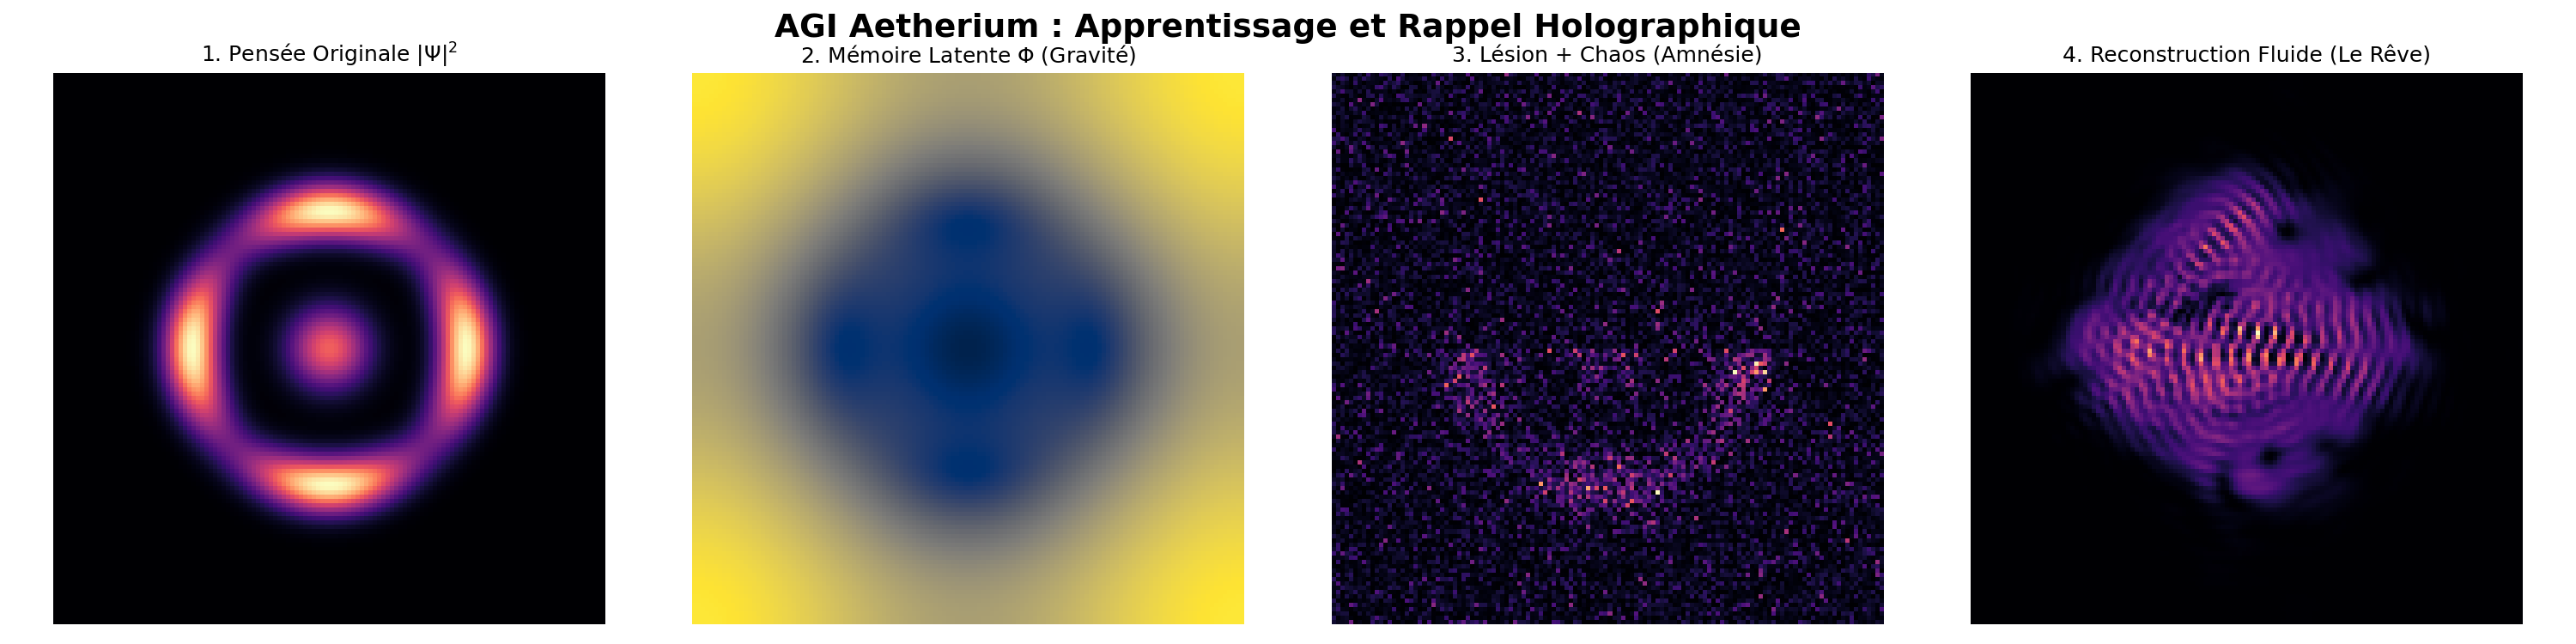

In [ ]:
from IPython.display import Image, display
display(Image('aetherium_agi_holographic.png'))